# MMFDB · Burst selection

**Burst selection** finds the individual single molecules that cross the
confocal spot. Here we simulate a two-colour smFRET measurement (so we know
the truth), store it in **MMFDB**, and detect bursts straight from the
database handle.

In [1]:
%matplotlib inline
import logging, warnings
for _n in ("numexpr", "mmfdb"):
    logging.getLogger(_n).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="nopython is set for njit")

import numpy as np
import matplotlib.pyplot as plt
from chisurf.plugins.burst.burst_analysis.api import BurstWorkflow

## Simulate a measurement and store it in MMFDB

`wf.simulate` generates diffusing molecules with tttrlib and registers the
result in MMFDB, returning a handle.

In [2]:
wf = BurstWorkflow.demo()
sim = wf.simulate(fret=(0.3, 0.7), exchange_rate=1.0, n_photons=300_000)
print("stored in MMFDB:", sim.handle)

stored in MMFDB: 28baafec-4cad-475d-a6ca-18bd65e9ecd4


## Detect bursts

`select_bursts` fetches the data by handle and runs the sliding-window burst
search. `min_photons` sets the smallest burst kept.

In [3]:
bursts = wf.select_bursts(sim.handle, setup=sim.setup, min_photons=20)
print(bursts)
table = bursts.table

<Bursts: 2056 bursts from simulation.spc>


## What did we select?

Each burst carries its photon count, duration, and count rate. Single-molecule
bursts cluster at small sizes and short durations.

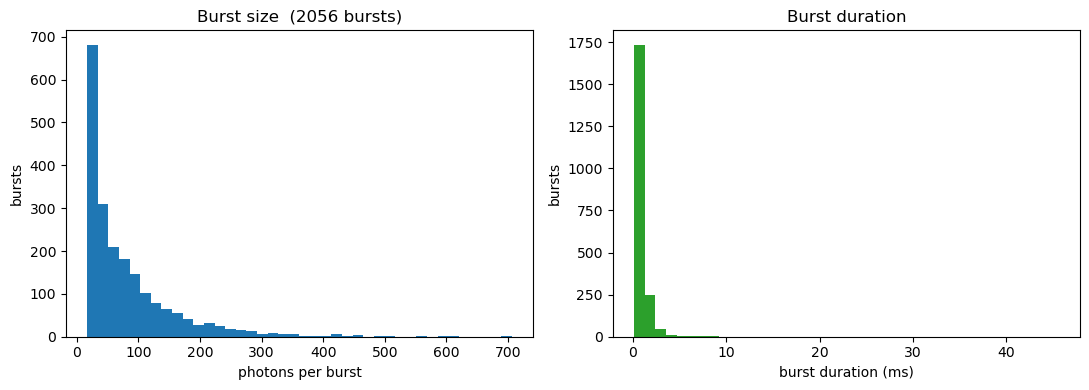

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(table["Number of Photons"], bins=40, color="#1f77b4")
ax[0].set_xlabel("photons per burst"); ax[0].set_ylabel("bursts")
ax[0].set_title(f"Burst size  ({len(table)} bursts)")
ax[1].hist(table["Duration (ms)"], bins=40, color="#2ca02c")
ax[1].set_xlabel("burst duration (ms)"); ax[1].set_ylabel("bursts")
ax[1].set_title("Burst duration")
fig.tight_layout(); plt.show()

The selected bursts feed the FRET analyses — see the BVA and H2MM examples.

In [5]:
wf.close()
print("Finished.")

Finished.
